In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

DATA_DIR = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction") 

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

In [3]:
def load_horizontal(well_id, split="train"):
    dir_ = TRAIN_DIR if split == "train" else TEST_DIR
    fn = dir_ / f"{well_id}__horizontal_well.csv"
    df = pd.read_csv(fn)
    df = df.sort_values("MD").reset_index(drop=True)
    return df

In [4]:
def load_typewell(well_id, split="train"):
    dir_ = TRAIN_DIR if split == "train" else TEST_DIR
    fn = dir_ / f"{well_id}__typewell.csv"
    df = pd.read_csv(fn)
    df = df.sort_values("TVT").reset_index(drop=True)
    return df

In [5]:
def list_wells(split="train"):
    dir_ = TRAIN_DIR if split == "train" else TEST_DIR
    files = sorted(dir_.glob("*__horizontal_well.csv"))
    return [f.name.split("__")[0] for f in files]

In [6]:
def baseline_tvt_prediction(h_df: pd.DataFrame) -> pd.Series:
    df = h_df.sort_values("MD").reset_index(drop=True)
    pred = df["TVT_input"].copy()

    known = ~pred.isna()
    # training fallback
    if ("TVT" in df.columns) and known.sum() < 2:
        return df["TVT"].copy()
    # test fallback
    if ("TVT" not in df.columns) and known.sum() < 2:
        mean_val = df["TVT_input"].dropna().mean() if df["TVT_input"].notna().any() else 0.0
        return pd.Series(mean_val, index=df.index)

    md_known = df.loc[known, "MD"].values
    tvt_known = df.loc[known, "TVT_input"].values
    md_all = df["MD"].values

    interp_all = np.interp(md_all, md_known, tvt_known)
    pred[~known] = interp_all[~known]
    return pred

In [7]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # per-well relative MD
    md_min, md_max = df["MD"].min(), df["MD"].max()
    df["MD_rel"] = (df["MD"] - md_min) / (md_max - md_min + 1e-6)

    # distance from geological surfaces
    surface_cols = ["ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"]
    for col in surface_cols:
        if col in df.columns:
            df[f"Z_minus_{col}"] = df["Z"] - df[col]

    # GR handling
    if "GR" in df.columns:
        df["GR_isna"] = df["GR"].isna().astype(int)
        df["GR_filled"] = df["GR"].ffill().bfill()
    else:
        df["GR_isna"] = 1
        df["GR_filled"] = 0.0

    return df

In [8]:
def add_gr_context_features(df: pd.DataFrame, window=(3, 7, 15, 31)) -> pd.DataFrame:
    df = df.copy()
    g = df["GR_filled"]

    for w in window:
        df[f"GR_roll_mean_{w}"] = g.rolling(w, center=True, min_periods=1).mean()
        df[f"GR_roll_std_{w}"] = g.rolling(w, center=True, min_periods=1).std().fillna(0)
    
    df["GR_diff"] = g.diff().fillna(0)
    df["GR_diff_abs"] = df["GR_diff"].abs()

    return df

In [9]:
def add_trajectory_derivatives(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["X", "Y", "Z"]:
        if col in df.columns:
            df[f"d{col}"] = df[col].diff().fillna(0)
    df["step_length"] = np.sqrt(
        df.get("dX", 0)**2 + df.get("dY", 0)**2 + df.get("dZ", 0)**2
    )
    return df

In [10]:
def build_horizontal_features(h: pd.DataFrame) -> pd.DataFrame:
    df = h.sort_values("MD").reset_index(drop=True)
    df = add_basic_features(df)
    df = add_gr_context_features(df)
    df = add_trajectory_derivatives(df)
    return df

In [11]:
def build_typewell_lookup(tw: pd.DataFrame):
    """
    Returns a function that, given an array of TVT values,
    returns interpolated GR and nearest-neighbor Geology.
    """
    tvt_vals = tw["TVT"].values
    gr_vals  = tw["GR"].values
    geo_vals = tw["Geology"].values  # may contain NaN

    def lookup(tvt_query: np.ndarray):
        # GR interpolation
        gr_interp = np.interp(tvt_query, tvt_vals, gr_vals)

        # nearest-neighbor geology
        geo_result = []
        for v in tvt_query:
            # find nearest index in typewell TVT
            idx = np.searchsorted(tvt_vals, v)
            if idx == 0:
                idx_nn = 0
            elif idx >= len(tvt_vals):
                idx_nn = len(tvt_vals) - 1
            else:
                # choose closer of idx-1 and idx
                if abs(tvt_vals[idx] - v) < abs(tvt_vals[idx-1] - v):
                    idx_nn = idx
                else:
                    idx_nn = idx - 1
            geo_result.append(geo_vals[idx_nn])
        geo_result = np.array(geo_result, dtype=object)
        return gr_interp, geo_result

    return lookup

In [12]:
def add_typewell_features(h: pd.DataFrame, tw: pd.DataFrame) -> pd.DataFrame:
    df = h.sort_values("MD").reset_index(drop=True).copy()

    # ensure baseline exists
    if "TVT_baseline" not in df.columns:
        df["TVT_baseline"] = baseline_tvt_prediction(df)

    lookup = build_typewell_lookup(tw)

    gr_tw, geo_tw = lookup(df["TVT_baseline"].values)

    df["GR_typewell_at_baseline"] = gr_tw
    df["GR_diff_to_typewell"] = df["GR_filled"] - df["GR_typewell_at_baseline"]

    # simple encoding of geology: category codes
    geo_series = pd.Series(geo_tw, index=df.index)
    df["Geo_typewell_raw"] = geo_series

    # turn geology into category codes
    df["Geo_typewell_code"] = geo_series.astype("category").cat.codes

    # (optional) one-hot, but be careful about dimensionality
    # geo_dummies = pd.get_dummies(geo_series, prefix="GeoTW")
    # df = pd.concat([df, geo_dummies], axis=1)

    return df

In [13]:
def build_residual_training_df_for_well(well_id: str) -> pd.DataFrame:
    h = load_horizontal(well_id, split="train")
    tw = load_typewell(well_id, split="train")

    h = h.sort_values("MD").reset_index(drop=True)

    # baseline
    h["TVT_baseline"] = baseline_tvt_prediction(h)

    # residual target
    h["TVT_residual"] = h["TVT"] - h["TVT_baseline"]

    # horizontal features
    df = build_horizontal_features(h)

    # attach baseline + residual + TVT
    df["TVT_baseline"] = h["TVT_baseline"]
    df["TVT_residual"] = h["TVT_residual"]
    df["TVT"] = h["TVT"]

    # add typewell-based features (needs GR_filled already)
    df = add_typewell_features(df, tw)

    df["well_id"] = well_id
    return df

In [15]:
train_wells = list_wells(split="train")
well_ids = np.array(train_wells)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = []
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(well_ids)):
    tr_wells = well_ids[tr_idx]
    va_wells = well_ids[va_idx]

    tr_parts, va_parts = [], []
    for w in tr_wells:
        tr_parts.append(build_residual_training_df_for_well(w))
    for w in va_wells:
        va_parts.append(build_residual_training_df_for_well(w))

    tr_df = pd.concat(tr_parts, ignore_index=True)
    va_df = pd.concat(va_parts, ignore_index=True)

    # choose features
    drop_cols = [
        "TVT", "TVT_input", "TVT_residual",
        "TVT_baseline", "well_id",
        "Geo_typewell_raw"   # non-numeric string
    ]
    feature_cols = [c for c in tr_df.columns if c not in drop_cols]

    X_tr = tr_df[feature_cols]
    y_tr = tr_df["TVT_residual"]
    X_va = va_df[feature_cols]
    y_va = va_df["TVT_residual"]

    model = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=fold
    )
    model.fit(X_tr, y_tr)

    residual_pred = model.predict(X_va)
    va_df["TVT_pred"] = residual_pred + va_df["TVT_baseline"]

    rmse = root_mean_squared_error(va_df["TVT"], va_df["TVT_pred"])
    fold_scores.append(rmse)
    print(f"Fold {fold}: RMSE={rmse:.3f}")

    models.append(model)

print("Typewell residual model CV RMSE mean:",
      np.mean(fold_scores),
      "std:", np.std(fold_scores))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.253275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8847
[LightGBM] [Info] Number of data points in the train set: 4048218, number of used features: 37
[LightGBM] [Info] Start training from score 1.386683
Fold 0: RMSE=15.094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.250863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8846
[LightGBM] [Info] Number of data points in the train set: 4060149, number of used features: 37
[LightGBM] [Info] Start training from score 1.417326
Fold 1: RMSE=12.103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.246277 seconds.
You can set `force_row_wise=true` to rem

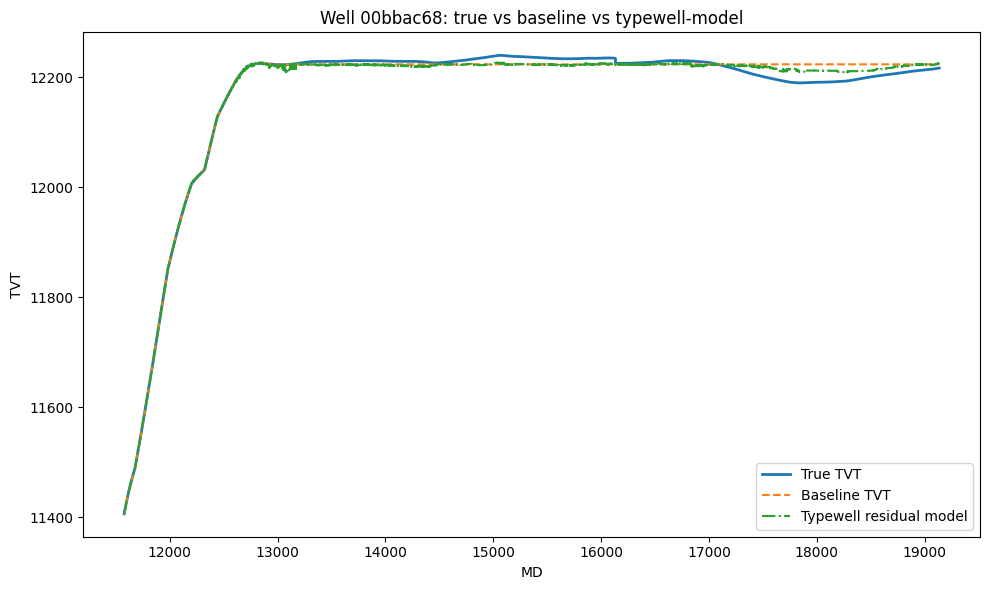

In [19]:
example_well = va_wells[0]

h = load_horizontal(example_well, split="train")
tw = load_typewell(example_well, split="train")

h = h.sort_values("MD").reset_index(drop=True)
h["TVT_baseline"] = baseline_tvt_prediction(h)

df_feat = build_horizontal_features(h)
df_feat["TVT_baseline"] = h["TVT_baseline"]
df_feat = add_typewell_features(df_feat, tw)

X_example = df_feat[feature_cols]  # reuse cols from above
resid_example = models[-1].predict(X_example)
h["TVT_pred"] = h["TVT_baseline"] + resid_example

plt.figure(figsize=(10, 6))
plt.plot(h["MD"], h["TVT"], label="True TVT", linewidth=2)
plt.plot(h["MD"], h["TVT_baseline"], label="Baseline TVT", linestyle="--")
plt.plot(h["MD"], h["TVT_pred"], label="Typewell residual model", linestyle="-.")
plt.xlabel("MD")
plt.ylabel("TVT")
plt.title(f"Well {example_well}: true vs baseline vs typewell-model")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
y_1_true = h["TVT"]
y_1_pred = h["TVT_pred"]
rmse_well = root_mean_squared_error(y_1_true, y_1_pred)
print("Well-level RMSE:", rmse_well)
print("TVT mean:", y_1_true.mean(), "TVT std:", y_1_true.std())
print("Pred mean:", y_1_pred.mean(), "Pred std:", y_1_pred.std())


Well-level RMSE: 10.297817862083727
TVT mean: 12173.249466860696 TVT std: 148.86671400795996
Pred mean: 12172.859251222384 Pred std: 148.15714868293463
